# ERA5 Visualization — Weather Model Interpretability Project

Визуализация трёх синоптических кейсов из ARCO ERA5:

1. **Storm Eunice** — 2022-02-18 12:00 UTC (взрывной циклогенез, Северная Атлантика/Британия)
2. **Европейская волна тепла / блокинг** — 2022-07-18 12:00 UTC
3. **Спокойный baseline** — 2021-10-05 12:00 UTC

Источник: `gs://gcp-public-data-arco-era5` (Analysis-Ready Cloud-Optimized ERA5, Google Research).


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams['figure.dpi'] = 110


## 1. Открываем ARCO ERA5

Основной массив: 31 приповерхностная переменная + переменные на 37 уровнях давления, 0.25°, часовое разрешение.


In [2]:
ARCO_URL = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'

ds = xr.open_zarr(ARCO_URL, storage_options=dict(token='anon'), chunks=None)

# ARCO stores longitude as 0..359.75; convert to -180..180 and sort so that
# regional slices crossing the prime meridian (e.g. North Atlantic/Europe) don't
# produce a seam artifact at lon=0.
ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby('longitude')

print(ds)


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud._storage_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud._storage_v2 past that date.
  warnings.warn(message, FutureWarning)
/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * time                                                             (time) datetime64[ns] 11MB ...
  * longitude                                                        (longitude) float32 6kB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind

## 2. Маппинг имён переменных: ARCO (длинные CDS-имена) → короткие GRIB-имена

Этот словарь переиспользуется в `02_saliency_experiment.ipynb` — модели (Pangu-Weather, Aurora) ожидают короткие имена.


In [3]:
# Короткие имена, которые ожидают Pangu-Weather / Aurora
ARCO_TO_SHORT = {
    '2m_temperature': 't2m',
    '10m_u_component_of_wind': 'u10',
    '10m_v_component_of_wind': 'v10',
    'mean_sea_level_pressure': 'msl',
    'geopotential': 'z',
    'specific_humidity': 'q',
    'temperature': 't',
    'u_component_of_wind': 'u',
    'v_component_of_wind': 'v',
}

# 13 уровней давления (гПа), которые требуются Pangu-Weather / Aurora
PRESSURE_LEVELS_HPA = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]

SURFACE_VARS = ['2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure']
UPPER_AIR_VARS = ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind']

print('Surface vars available:', all(v in ds.data_vars for v in SURFACE_VARS))
print('Upper-air vars available:', all(v in ds.data_vars for v in UPPER_AIR_VARS))
print('Levels present in dataset:', ds.level.values if 'level' in ds.coords else 'N/A')


Surface vars available: True
Upper-air vars available: True
Levels present in dataset: [   1    2    3    5    7   10   20   30   50   70  100  125  150  175
  200  225  250  300  350  400  450  500  550  600  650  700  750  775
  800  825  850  875  900  925  950  975 1000]


## 3. Три синоптических кейса


In [4]:
CASES = {
    'storm_eunice':   {'time': '2022-02-18T12:00', 'label': 'Storm Eunice (18 Feb 2022, 12:00 UTC)'},
    'heatwave_block': {'time': '2022-07-18T12:00', 'label': 'European heatwave / blocking (18 Jul 2022, 12:00 UTC)'},
    'quiet_baseline': {'time': '2021-10-05T12:00', 'label': 'Quiet baseline (5 Oct 2021, 12:00 UTC)'},
}


## 4. Вырезаем нужные переменные и уровни для каждого кейса

Тянем только 13 нужных уровней (не все 37) и только нужный временной срез — иначе скачивание будет неоправданно долгим.


In [5]:
def load_case(time_str):
    """Load surface + upper-air fields for one timestamp, sliced to the 13 required pressure levels."""
    snapshot = ds.sel(time=time_str)
    surface = snapshot[SURFACE_VARS].load()
    upper_air = snapshot[UPPER_AIR_VARS].sel(level=PRESSURE_LEVELS_HPA).load()
    return surface, upper_air

case_data = {}
for key, meta in CASES.items():
    print(f'Loading {key} ({meta["time"]})...')
    surface, upper_air = load_case(meta['time'])
    case_data[key] = {'surface': surface, 'upper_air': upper_air}
print('Done.')


Loading storm_eunice (2022-02-18T12:00)...


Loading heatwave_block (2022-07-18T12:00)...


Loading quiet_baseline (2021-10-05T12:00)...


Done.


## 5. Визуализация: T2M, MSLP, ветер (10м), Z500

Для каждого кейса — 4 карты в один ряд, чтобы легко сравнивать три режима между собой.


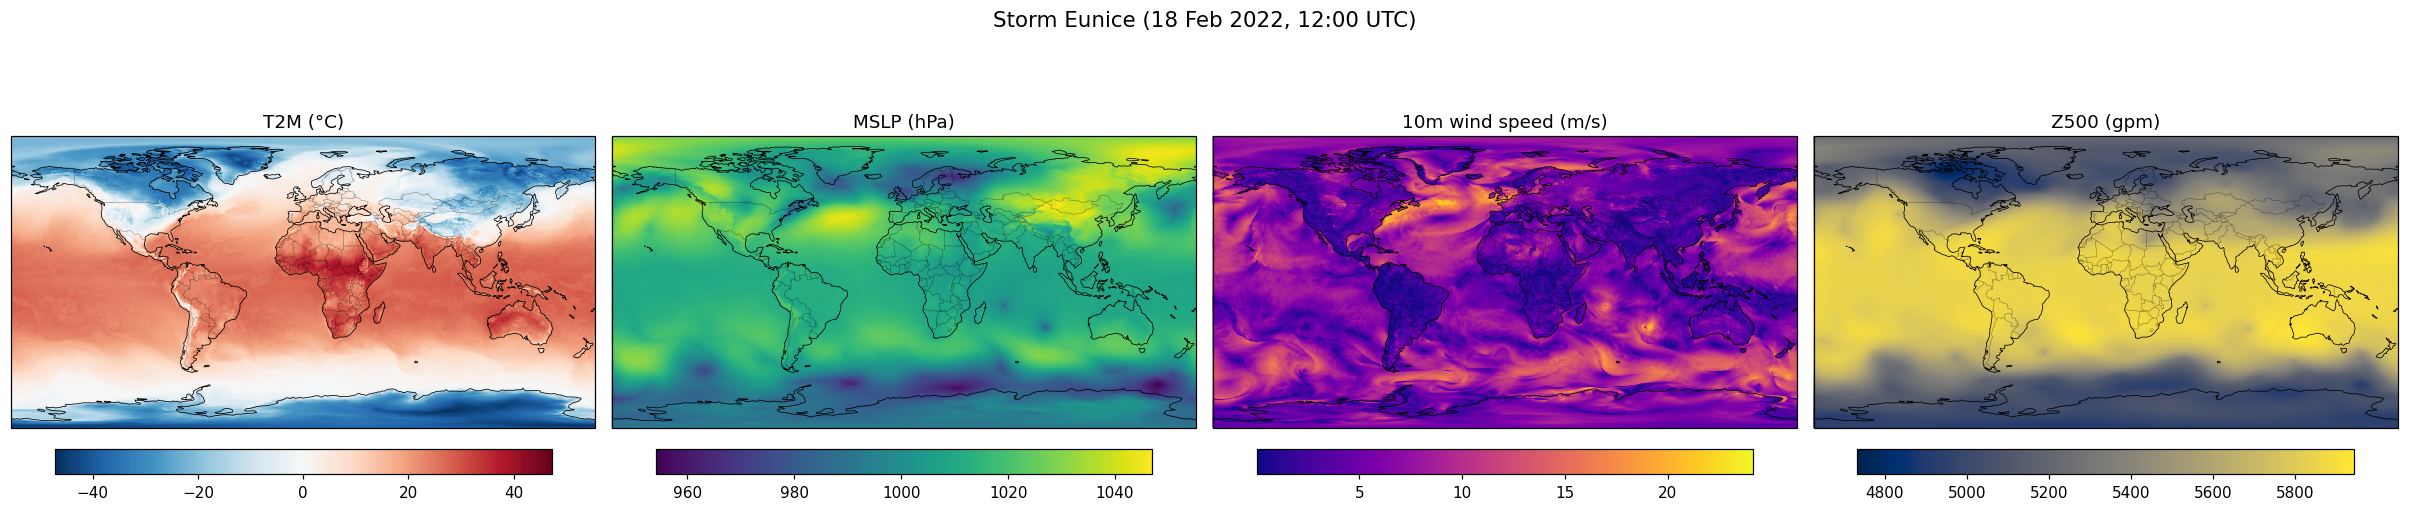

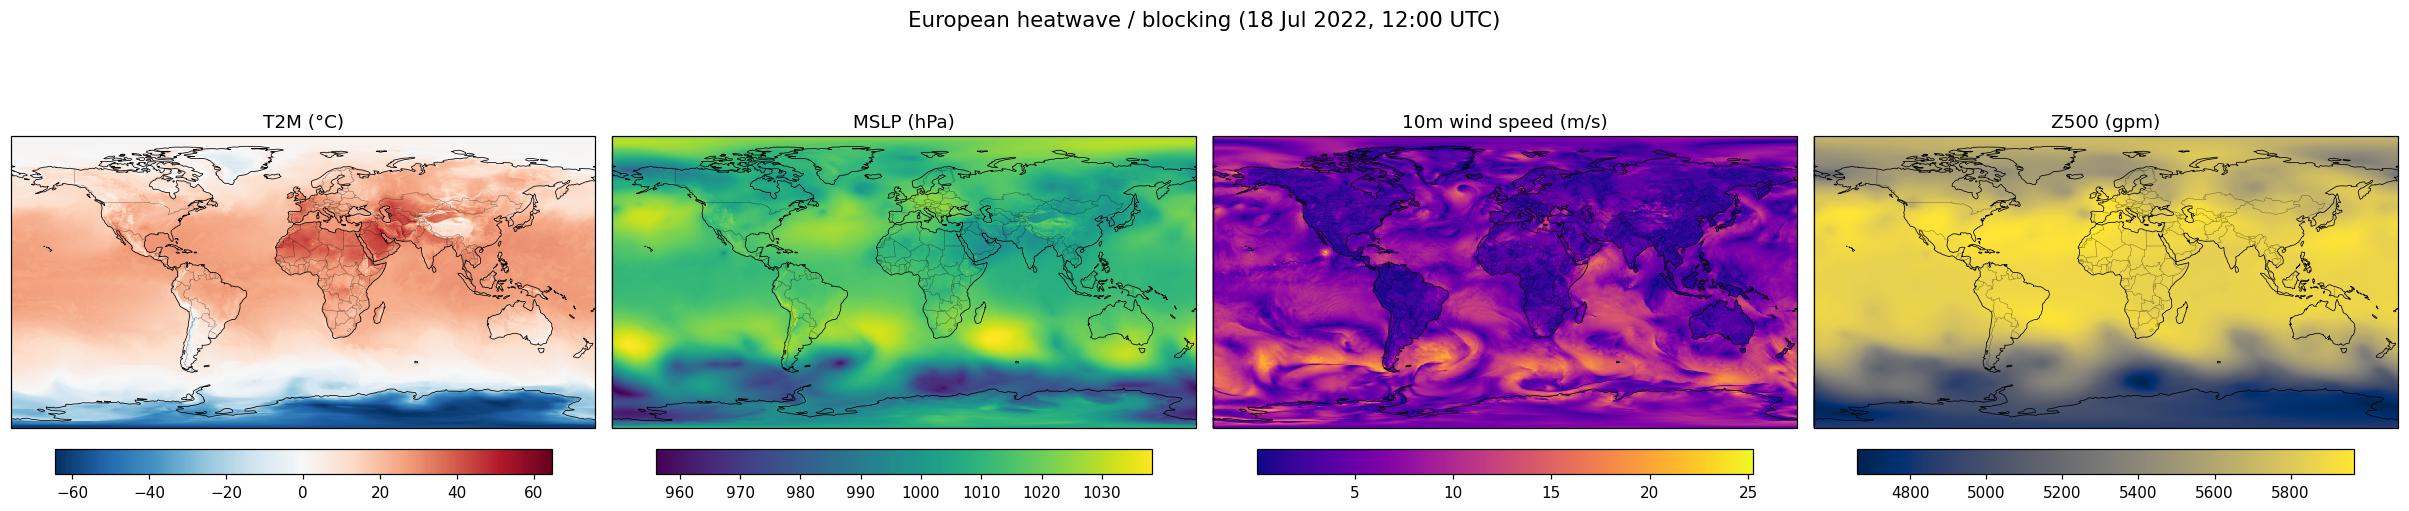

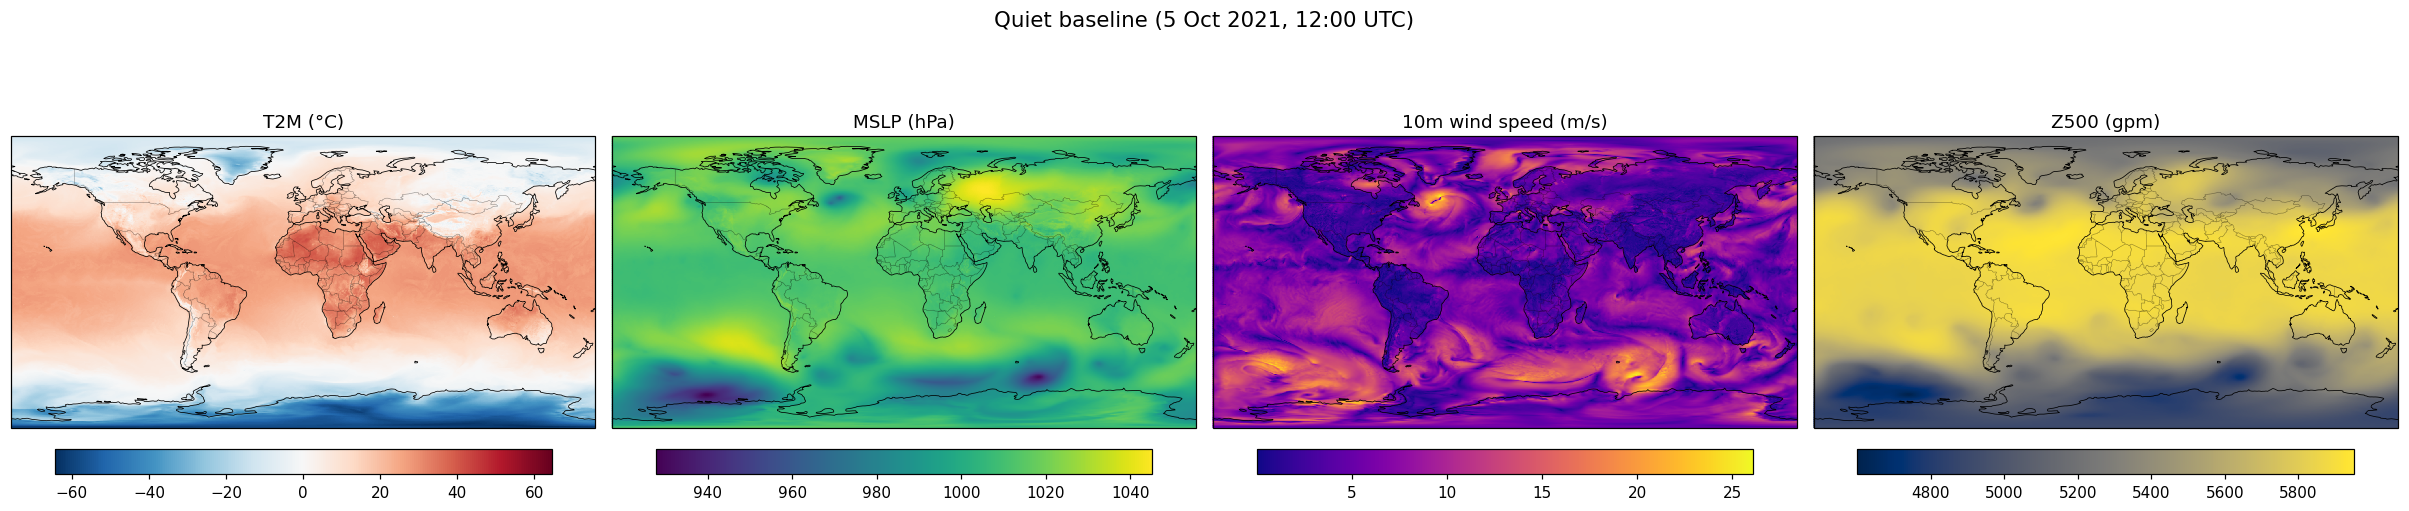

In [6]:
def plot_case(key):
    meta = CASES[key]
    surface = case_data[key]['surface']
    upper_air = case_data[key]['upper_air']

    t2m = surface['2m_temperature'] - 273.15  # K -> C
    msl = surface['mean_sea_level_pressure'] / 100  # Pa -> hPa
    u10 = surface['10m_u_component_of_wind']
    v10 = surface['10m_v_component_of_wind']
    wind_speed = np.sqrt(u10**2 + v10**2)
    z500 = upper_air['geopotential'].sel(level=500) / 9.80665  # m^2/s^2 -> geopotential meters

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.suptitle(meta['label'], fontsize=14, y=1.05)

    panels = [
        (t2m, 'T2M (°C)', 'RdBu_r'),
        (msl, 'MSLP (hPa)', 'viridis'),
        (wind_speed, '10m wind speed (m/s)', 'plasma'),
        (z500, 'Z500 (gpm)', 'cividis'),
    ]

    for ax, (field, title, cmap) in zip(axes, panels):
        ax.set_global()
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        im = field.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, add_colorbar=False)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.85)

    plt.tight_layout()
    plt.savefig(f'figures/{key}_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

import os
os.makedirs('figures', exist_ok=True)

for key in CASES:
    plot_case(key)


## 6. Региональный zoom (Северная Атлантика/Европа) для Storm Eunice и волны тепла

Глобальный вид скрывает детали — для двух экстремальных кейсов даём региональный крупный план.


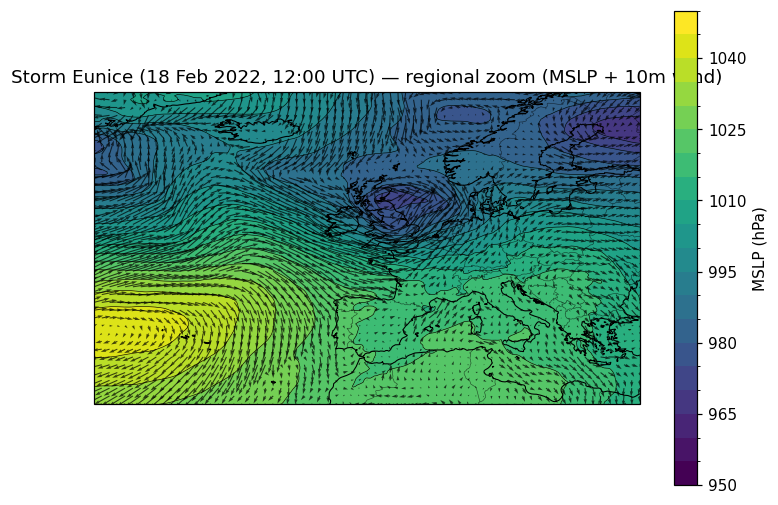

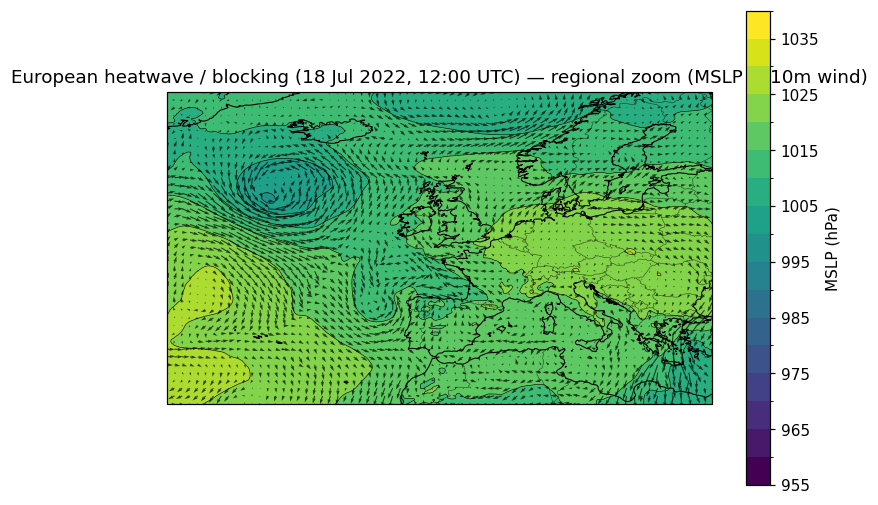

In [7]:
def plot_regional_zoom(key, lon_range=(-40, 30), lat_range=(30, 70)):
    meta = CASES[key]
    surface = case_data[key]['surface']
    msl = surface['mean_sea_level_pressure'] / 100
    u10 = surface['10m_u_component_of_wind']
    v10 = surface['10m_v_component_of_wind']

    fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([*lon_range, *lat_range], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.6)

    cf = msl.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=20, cmap='viridis', add_colorbar=True,
                            cbar_kwargs={'label': 'MSLP (hPa)', 'shrink': 0.8})
    msl.plot.contour(ax=ax, transform=ccrs.PlateCarree(), levels=20, colors='k', linewidths=0.4)

    step = 4  # subsample wind barbs for readability
    ax.quiver(u10.longitude[::step], u10.latitude[::step],
              u10.values[::step, ::step], v10.values[::step, ::step],
              transform=ccrs.PlateCarree(), scale=400, width=0.002, alpha=0.7)

    ax.set_title(f"{meta['label']} — regional zoom (MSLP + 10m wind)")
    plt.savefig(f'figures/{key}_regional_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_regional_zoom('storm_eunice')
plot_regional_zoom('heatwave_block')


## 7. Сохранение подготовленных данных для следующего ноутбука

Сохраняем сырые срезы (surface + upper_air на 13 уровнях) в NetCDF, чтобы `02_saliency_experiment.ipynb` не тянул их из ARCO заново.


In [8]:
import os
os.makedirs('data', exist_ok=True)

for key in CASES:
    case_data[key]['surface'].to_netcdf(f'data/{key}_surface.nc')
    case_data[key]['upper_air'].to_netcdf(f'data/{key}_upper_air.nc')

print('Saved:', os.listdir('data'))


Saved: ['quiet_baseline_surface.nc', 'heatwave_block_surface.nc', 'heatwave_block_upper_air.nc', 'storm_eunice_upper_air.nc', 'quiet_baseline_upper_air.nc', 'storm_eunice_surface.nc']
